# Experiment 08 (Advanced): Advanced K-Means Clustering & Cluster Validation Diagnostics
## Title: Comprehensive Analysis: K-Means++, WCSS Elbow Curve, Silhouette Analysis, Calinski-Harabasz & Davies-Bouldin Metrics, Voronoi Tessellation, and PCA Dimensionality Reduction

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Advanced Libraries & Setup Environment

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")
np.random.seed(33)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load Dataset & Feature Standardization

In [2]:
iris      = load_iris(as_frame=True)
df_iris   = iris.frame

x_iris    = df_iris.drop('target', axis=1)

scaler    = StandardScaler()
x_iris_sc = scaler.fit_transform(x_iris)

print(f"Iris Dataset Shape          : {x_iris.shape}")
print(f"Standardized Features Shape : {x_iris_sc.shape}")

Iris Dataset Shape          : (150, 4)
Standardized Features Shape : (150, 4)


### Step 3: WCSS Elbow Method & Internal Validation Metrics

In [3]:
wcss, sil_scores, ch_scores, db_scores = [], [], [], []
k_range = list(range(2, 9))

for k in k_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=33)
    labels = km.fit_predict(x_iris_sc)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(x_iris_sc, labels))
    ch_scores.append(calinski_harabasz_score(x_iris_sc, labels))
    db_scores.append(davies_bouldin_score(x_iris_sc, labels))

metrics_df = pd.DataFrame({
    'k'                 : k_range,
    'WCSS'              : wcss,
    'Silhouette'        : sil_scores,
    'Calinski-Harabasz' : ch_scores,
    'Davies-Bouldin'    : db_scores
})

print("Internal Cluster Validation Metrics for KMeans Clustering on Iris Dataset: ")
print(metrics_df.to_string(index=False))

Internal Cluster Validation Metrics for KMeans Clustering on Iris Dataset: 
 k       WCSS  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2 222.361705    0.581750         251.349339        0.593313
 3 139.820496    0.459948         241.904402        0.833595
 4 114.092547    0.386941         207.265914        0.869814
 5  90.833372    0.349391         203.199440        0.931361
 6  81.509782    0.327676         183.199095        0.975498
 7  72.386018    0.342545         173.718631        0.901006
 8  64.066061    0.344666         169.696757        0.939308


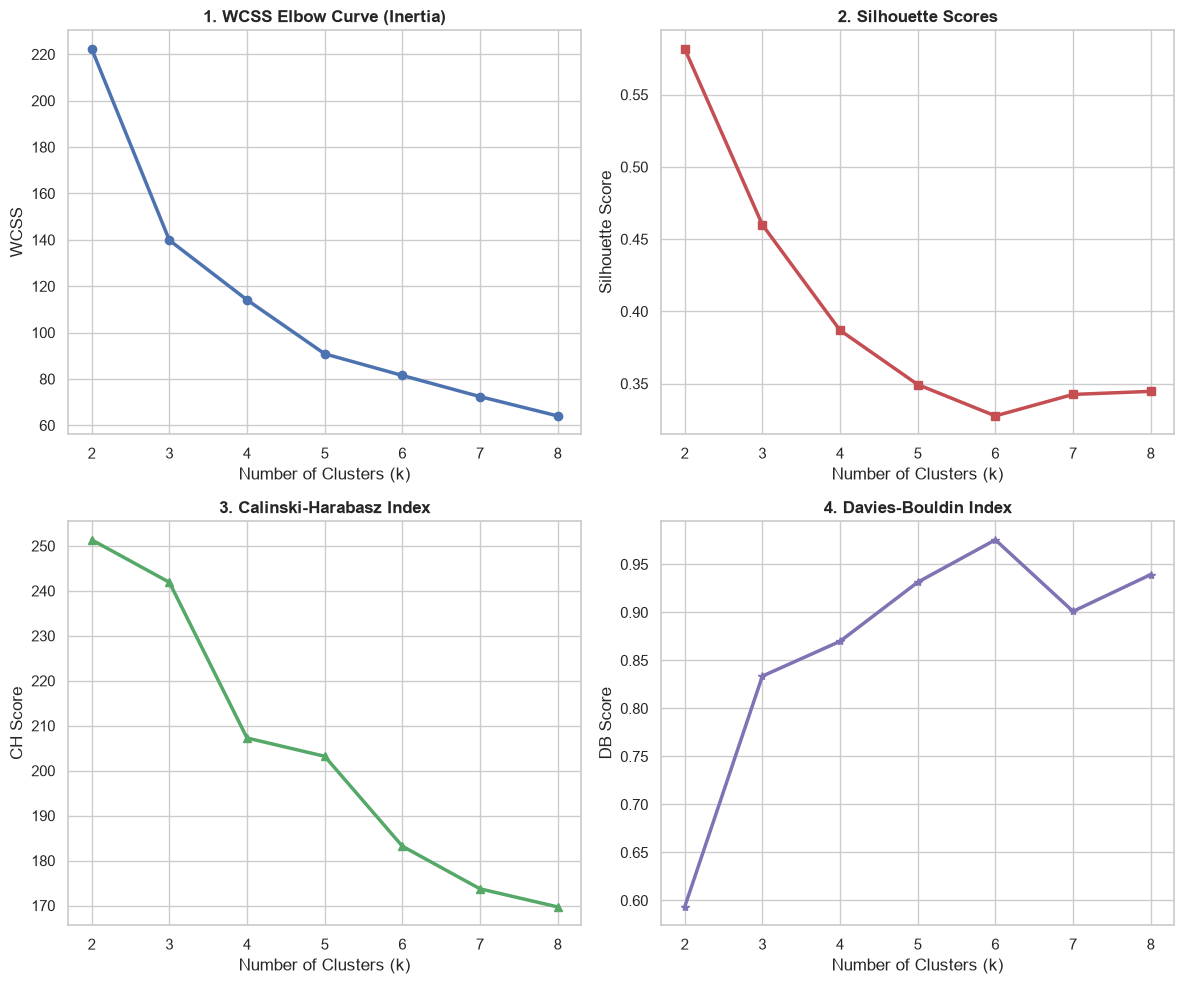

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
axes[0].plot(k_range, wcss, "bo-", linewidth=2.5)
axes[0].set_title("1. WCSS Elbow Curve (Inertia)", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS")

axes[1].plot(k_range, sil_scores, "rs-", linewidth=2.5)
axes[1].set_title("2. Silhouette Scores", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

axes[2].plot(k_range, ch_scores, "g^-", linewidth=2.5)
axes[2].set_title("3. Calinski-Harabasz Index", fontweight="bold")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("CH Score")

axes[3].plot(k_range, db_scores, "m*-", linewidth=2.5)
axes[3].set_title("4. Davies-Bouldin Index", fontweight="bold")
axes[3].set_xlabel("Number of Clusters (k)")
axes[3].set_ylabel("DB Score")

plt.tight_layout()
plt.show()

### Step 4: PCA 2D Cluster Centroids & Scatter Visualization

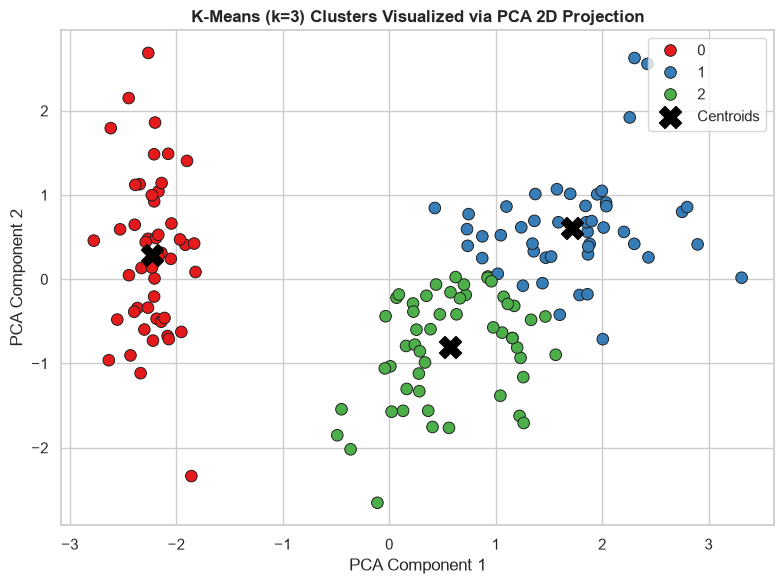

In [5]:
pca   = PCA(n_components=2)
x_pca = pca.fit_transform(x_iris_sc)

km_opt         = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=33)
cluster_labels = km_opt.fit_predict(x_iris_sc)
centroids_pca  = pca.transform(km_opt.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=cluster_labels, palette="Set1", s=70, edgecolor="k")
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=250, label="Centroids")
plt.title("K-Means (k=3) Clusters Visualized via PCA 2D Projection", fontweight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: Voronoi Tessellation on Synthetic 2D Data

In [6]:
x_blob, _   = make_blobs(n_samples=240, centers=3, cluster_std=1.15, random_state=33)
scaler_blob = StandardScaler()
x_blob_sc   = scaler_blob.fit_transform(x_blob)

km_blob     = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=33)
blob_labels = km_blob.fit_predict(x_blob_sc)
centers     = km_blob.cluster_centers_

x_min, x_max = x_blob_sc[:, 0].min() - 0.5, x_blob_sc[:, 0].max() + 0.5
y_min, y_max = x_blob_sc[:, 1].min() - 0.5, x_blob_sc[:, 1].max() + 0.5
xx, yy       = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
z            = km_blob.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


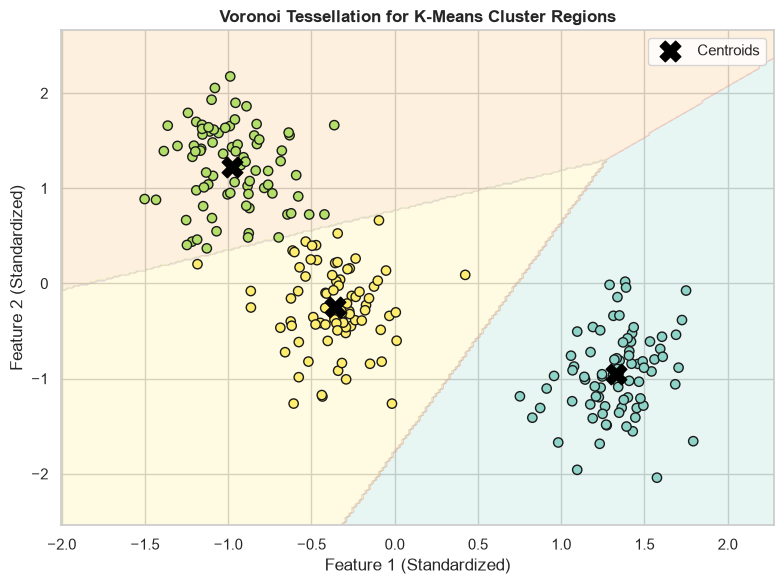

In [7]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, z, alpha=0.2, cmap='Set3')
plt.scatter(x_blob_sc[:, 0], x_blob_sc[:, 1], c=blob_labels, cmap='Set3', s=45, edgecolor='k')
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=220, label='Centroids')
plt.title('Voronoi Tessellation for K-Means Cluster Regions', fontweight='bold')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.tight_layout()
plt.show()

### Step 6: Conclusion & Summary
1. **Elbow, Silhouette, CH, and DB plots** give a more complete internal validation view of cluster quality.
2. **K-Means++** effectively mitigates poor local minima convergence during centroid initialization.
3. **Voronoi tessellation** makes centroid-based decision regions visible and explains how K-Means partitions space.

**Experiment Completed Successfully.**